Puedes pedir las versiones impresa y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

Downloaded thinkpython.py
Downloaded diagram.py


# Clases y funciones

A estas alturas sabes cómo usar funciones para organizar código y cómo usar tipos integrados para organizar datos.
El siguiente paso es la **programación orientada a objetos**, que usa tipos definidos por el programador para organizar tanto código como datos.

La programación orientada a objetos es un tema amplio, así que avanzaremos gradualmente.
En este capítulo, empezaremos con código que no es idiomático -- es decir, no es el tipo de código que escriben los programadores con experiencia -- pero es un buen punto de partida.
En los dos capítulos siguientes, usaremos características adicionales para escribir código más idiomático.

## Tipos definidos por el programador

Hemos usado muchos de los tipos integrados de Python -- ahora definiremos un tipo nuevo.
Como primer ejemplo, crearemos un tipo llamado `Time` que representa una hora del día.
Un tipo definido por el programador también se llama **clase**.
Una definición de clase se ve así:

In [3]:
class Time:
    """Represents a time of day."""

La cabecera indica que la nueva clase se llama `Time`.
El cuerpo es un docstring que explica para qué sirve la clase.
Definir una clase crea un **objeto de clase**.

El objeto de clase es como una fábrica para crear objetos.
Para crear un objeto `Time`, llamas a `Time` como si fuera una función.

In [4]:
lunch = Time()

El resultado es un objeto nuevo cuyo tipo es `__main__.Time`, donde `__main__` es el nombre del módulo donde se define `Time`.

In [5]:
type(lunch)

__main__.Time

Cuando imprimes un objeto, Python te dice de qué tipo es y dónde está almacenado en memoria (el prefijo `0x` significa que el número siguiente está en hexadecimal).

In [6]:
print(lunch)

Crear un objeto nuevo se llama **instanciación**, y el objeto es una **instancia** de la clase.

## Atributos

Un objeto puede contener variables, que se llaman **atributos**.
Podemos crear atributos usando notación de punto.

In [7]:
lunch.hour = 11
lunch.minute = 59
lunch.second = 1

Este ejemplo crea atributos llamados `hour`, `minute` y `second`, que contienen las horas, minutos y segundos de la hora `11:59:01`, que es la hora de comer por lo que a mí respecta.

El siguiente diagrama muestra el estado de `lunch` y sus atributos después de estas asignaciones.

In [8]:
from diagram import make_frame, make_binding

d1 = dict(hour=11, minute=59, second=1)
frame = make_frame(d1, name='Time', dy=-0.3, offsetx=0.48)
binding = make_binding('lunch', frame)

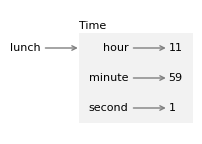

In [9]:
from diagram import diagram, adjust

width, height, x, y = [1.77, 1.24, 0.25, 0.86]
ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
#adjust(x, y, bbox)

La variable `lunch` se refiere a un objeto `Time`, que contiene tres atributos.
Cada atributo se refiere a un entero.
Un diagrama de estado como este -- que muestra un objeto y sus atributos -- se llama **diagrama de objeto**.

Puedes leer el valor de un atributo usando el operador de punto.

In [10]:
lunch.hour

11

Puedes usar un atributo como parte de cualquier expresión.

In [11]:
total_minutes = lunch.hour * 60 + lunch.minute
total_minutes

719

Y puedes usar el operador de punto en una expresión dentro de una f-string.

In [13]:
f'{lunch.hour}:{lunch.minute}:{lunch.second}'

'11:59:1'

Pero observa que el ejemplo anterior no está en el formato estándar.
Para arreglarlo, tenemos que imprimir los atributos `minute` y `second` con un cero inicial.
Podemos hacerlo extendiendo las expresiones entre llaves con un **especificador de formato**.
En el siguiente ejemplo, los especificadores de formato indican que `minute` y `second` deberían mostrarse con al menos dos dígitos y un cero inicial si hace falta.

In [14]:
f'{lunch.hour}:{lunch.minute:02d}:{lunch.second:02d}'

'11:59:01'

Usaremos esta f-string para escribir una función que muestra el valor de un objeto `Time`.
Puedes pasar un objeto como argumento de la forma habitual.
Por ejemplo, la siguiente función toma un objeto `Time` como argumento.

In [15]:
def print_time(time):
    s = f'{time.hour:02d}:{time.minute:02d}:{time.second:02d}'
    print(s)

Cuando la llamamos, podemos pasar `lunch` como argumento.

In [16]:
print_time(lunch)

11:59:01


## Objetos como valores de retorno

Las funciones pueden devolver objetos. Por ejemplo, `make_time` toma parámetros llamados `hour`, `minute` y `second`, los almacena como atributos en un objeto `Time` y devuelve el objeto nuevo.

In [17]:
def make_time(hour, minute, second):
    time = Time()
    time.hour = hour
    time.minute = minute
    time.second = second
    return time

Puede sorprender que los parámetros tengan los mismos nombres que los atributos, pero esa es una forma habitual de escribir una función como esta.
Así usamos `make_time` para crear un objeto `Time`.

In [18]:
time = make_time(11, 59, 1)
print_time(time)

11:59:01


## Los objetos son mutables

Supón que vas a una proyección de una película, como *Monty Python and the Holy Grail*, que empieza a las `9:20 PM` y dura `92` minutos, que es una hora y `32` minutos.
¿A qué hora terminará la película?

Primero, crearemos un objeto `Time` que representa la hora de inicio.

In [19]:
start = make_time(9, 20, 0)
print_time(start)

09:20:00


Para encontrar la hora de fin, podemos modificar los atributos del objeto `Time`, añadiendo la duración de la película.

In [20]:
start.hour += 1
start.minute += 32
print_time(start)

10:52:00


La película terminará a las 10:52 PM.

Encapsulemos este cálculo en una función y generalicémoslo para que tome la duración de la película en tres parámetros: `hours`, `minutes` y `seconds`.

In [21]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

Aquí tienes un ejemplo que demuestra el efecto.

In [22]:
start = make_time(9, 20, 0)
increment_time(start, 1, 32, 0)
print_time(start)

10:52:00


El siguiente stack diagram muestra el estado del programa justo antes de que `increment_time` modifique el objeto.

In [23]:
from diagram import Frame, Binding, Value, Stack

d1 = dict(hour=9, minute=20, second=0)
obj1 = make_frame(d1, name='Time', dy=-0.25, offsetx=0.78)

binding1 = make_binding('start', frame, draw_value=False, dx=0.7)
frame1 = Frame([binding1], name='__main__', loc='left', offsetx=-0.2)

binding2 = Binding(Value('time'), draw_value=False, dx=0.7, dy=0.35)
binding3 = make_binding('hours', 1)
binding4 = make_binding('minutes',32)
binding5 = make_binding('seconds', 0)
frame2 = Frame([binding2, binding3, binding4, binding5], name='increment_time',
               loc='left', dy=-0.25, offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

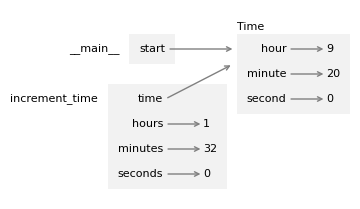

In [24]:
from diagram import Bbox

width, height, x, y = [3.4, 1.89, 1.75, 1.5]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = obj1.draw(ax, x+0.23, y)
bbox = Bbox.union([bbox1, bbox2])
# adjust(x, y, bbox)

Dentro de la función, `time` es un alias de `start`, así que cuando se modifica `time`, cambia `start`.

Esta función funciona, pero después de ejecutarse nos quedamos con una variable llamada `start` que se refiere a un objeto que representa la hora de *fin*, y ya no tenemos un objeto que represente la hora de inicio.
Sería mejor dejar `start` sin cambios y crear un objeto nuevo para representar la hora de fin.
Podemos hacerlo copiando `start` y modificando la copia.

## Copiar

El módulo `copy` proporciona una función llamada `copy` que puede duplicar cualquier objeto.
Podemos importarla así.

In [25]:
from copy import copy

Para ver cómo funciona, empecemos con un objeto `Time` nuevo que representa la hora de inicio de la película.

In [26]:
start = make_time(9, 20, 0)

Y hagamos una copia.

In [27]:
end = copy(start)

Ahora `start` y `end` contienen los mismos datos.

In [28]:
print_time(start)
print_time(end)

09:20:00
09:20:00


Pero el operador `is` confirma que no son el mismo objeto.

In [29]:
start is end

False

Veamos qué hace el operador `==`.

In [30]:
start == end

False

Podrías esperar que `==` produzca `True` porque los objetos contienen los mismos datos.
Pero para clases definidas por el programador, el comportamiento por defecto del operador `==` es el mismo que el del operador `is` -- comprueba identidad, no equivalencia.

## Funciones puras

Podemos usar `copy` para escribir funciones puras que no modifican sus parámetros.
Por ejemplo, aquí tienes una función que toma un objeto `Time` y una duración en horas, minutos y segundos.
Hace una copia del objeto original, usa `increment_time` para modificar la copia y la devuelve.

In [31]:
def add_time(time, hours, minutes, seconds):
    total = copy(time)
    increment_time(total, hours, minutes, seconds)
    return total

Así la usamos.

In [32]:
end = add_time(start, 1, 32, 0)
print_time(end)

10:52:00


El valor de retorno es un objeto nuevo que representa la hora de fin de la película.
Y podemos confirmar que `start` no ha cambiado.

In [33]:
print_time(start)

09:20:00


`add_time` es una **función pura** porque no modifica ninguno de los objetos que se le pasan como argumentos y su único efecto es devolver un valor.

Cualquier cosa que se pueda hacer con funciones impuras también se puede hacer con funciones puras.
De hecho, algunos lenguajes de programación solo permiten funciones puras.
Los programas que usan funciones puras pueden ser menos propensos a errores, pero las funciones impuras a veces son convenientes y pueden ser más eficientes.

En general, te sugiero que escribas funciones puras siempre que sea razonable y recurras a funciones impuras solo si hay una ventaja convincente.
Este enfoque podría llamarse un **estilo de programación funcional**.

## Prototype and patch

En el ejemplo anterior, `increment_time` y `add_time` parecen funcionar, pero si probamos otro ejemplo veremos que no son del todo correctas.

Supón que llegas al cine y descubres que la película empieza a las `9:40`, no a las `9:20`.
Esto es lo que ocurre cuando calculamos la hora de fin actualizada.

In [34]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

10:72:00


El resultado no es una hora válida.
El problema es que `increment_time` no trata los casos en los que el número de segundos o minutos suma más de `60`.

Aquí tienes una versión mejorada que comprueba si `second` supera o iguala `60` -- si es así, incrementa `minute` -- y luego comprueba si `minute` supera o iguala `60` -- si es así, incrementa `hour`.

In [35]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

    if time.second >= 60:
        time.second -= 60
        time.minute += 1

    if time.minute >= 60:
        time.minute -= 60
        time.hour += 1

Arreglar `increment_time` también arregla `add_time`, que la usa.
Así que ahora el ejemplo anterior funciona correctamente.

In [36]:
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


Pero esta función todavía no es correcta, porque los argumentos podrían ser mayores que `60`.
Por ejemplo, supón que recibimos la duración como `92` minutos, en lugar de `1` hora y `32` minutos.
Podríamos llamar a `add_time` así.

In [37]:
end = add_time(start, 0, 92, 0)
print_time(end)

10:72:00


El resultado no es una hora válida.
Así que probemos un enfoque distinto, usando la función `divmod`.
Haremos una copia de `start` y la modificaremos incrementando el atributo `minute`.

In [38]:
end = copy(start)
end.minute = start.minute + 92
end.minute

132

Ahora `minute` es `132`, que son `2` horas y `12` minutos.
Podemos usar `divmod` para dividir por `60` y devolver el número de horas completas y el número de minutos sobrantes.

In [39]:
carry, end.minute = divmod(end.minute, 60)
carry, end.minute

(2, 12)

Ahora `minute` es correcto, y podemos añadir las horas a `hour`.

In [40]:
end.hour += carry
print_time(end)

11:12:00


El resultado es una hora válida.
Podemos hacer lo mismo con `hour` y `second`, y encapsular todo el proceso en una función.

In [41]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

    carry, time.second = divmod(time.second, 60)
    carry, time.minute = divmod(time.minute + carry, 60)
    carry, time.hour = divmod(time.hour + carry, 24)

Con esta versión de `increment_time`, `add_time` funciona correctamente, incluso si los argumentos superan `60`.

In [42]:
end = add_time(start, 0, 90, 120)
print_time(end)

11:12:00


Esta sección demuestra un plan de desarrollo de programas que llamo **prototype and patch**.
Empezamos con un prototipo simple que funcionaba correctamente para el primer ejemplo.
Luego lo probamos con ejemplos más difíciles -- cuando encontramos un error, modificamos el programa para corregirlo, como poner un parche en un neumático pinchado.

Este enfoque puede ser efectivo, especialmente si todavía no tienes una comprensión profunda del problema.
Pero las correcciones incrementales pueden generar código innecesariamente complicado -- porque trata muchos casos especiales -- y poco fiable -- porque es difícil saber si has
encontrado todos los errores.

## Design-first development

Un plan alternativo es **design-first development**, que implica más planificación antes de prototipar. En un proceso design-first, a veces una idea de alto nivel sobre el problema hace que la programación sea mucho más sencilla.

En este caso, la idea es que podemos pensar en un objeto `Time` como un número de tres dígitos en base 60 -- también conocida como sexagesimal.
El atributo `second` es la "columna de las unidades", el atributo `minute` es la "columna de los sesenta",
y el atributo `hour` es la "columna de los treinta y seis cientos".
Cuando escribimos `increment_time`, en realidad estábamos haciendo suma en base 60, por eso teníamos que llevar de una columna a la siguiente.

Esta observación sugiere otro enfoque para todo el problema -- podemos convertir objetos `Time` en enteros y aprovechar que Python sabe hacer aritmética de enteros.

Aquí tienes una función que convierte de un `Time` a un entero.

In [43]:
def time_to_int(time):
    minutes = time.hour * 60 + time.minute
    seconds = minutes * 60 + time.second
    return seconds

El resultado es el número de segundos desde el comienzo del día.
Por ejemplo, `01:01:01` es `1` hora, `1` minuto y `1` segundo desde el comienzo del día, que es la suma de `3600` segundos, `60` segundos y `1` segundo.

In [44]:
time = make_time(1, 1, 1)
print_time(time)
time_to_int(time)

01:01:01


3661

Y aquí tienes una función que va en la otra dirección -- convierte un entero en un objeto `Time` -- usando la función `divmod`.

In [45]:
def int_to_time(seconds):
    minute, second = divmod(seconds, 60)
    hour, minute = divmod(minute, 60)
    return make_time(hour, minute, second)

Podemos probarla convirtiendo el ejemplo anterior de vuelta a un `Time`.

In [49]:
time = int_to_time(3661)
print_time(time)

01:01:01


Usando estas funciones, podemos escribir una versión más concisa de `add_time`.

In [50]:
def add_time(time, hours, minutes, seconds):
    duration = make_time(hours, minutes, seconds)
    seconds = time_to_int(time) + time_to_int(duration)
    return int_to_time(seconds)

La primera línea convierte los argumentos en un objeto `Time` llamado `duration`.
La segunda línea convierte `time` y `duration` a segundos y los suma.
La tercera línea convierte la suma en un objeto `Time` y lo devuelve.

Así funciona.

In [48]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


En cierto sentido, convertir de base 60 a base 10 y de vuelta es más difícil que
simplemente tratar con horas. La conversión de base es más abstracta; nuestra intuición
para trabajar con valores de tiempo es mejor.

Pero si tenemos la idea de tratar las horas como números en base 60 -- e invertimos el esfuerzo de escribir las funciones de conversión `time_to_int` e `int_to_time` -- obtenemos un programa más corto, más fácil de leer y depurar, y más fiable.

También es más fácil añadir características más adelante. Por ejemplo, imagina restar dos objetos `Time` para encontrar la duración entre ellos.
El enfoque ingenuo es implementar la resta con préstamo.
Usar las funciones de conversión es más fácil y tiene más probabilidades de ser correcto.

Irónicamente, a veces hacer un problema más difícil -- o más general -- lo hace más fácil, porque hay menos casos especiales y menos oportunidades de error.

## Depuración

Python proporciona varias funciones integradas que son útiles para probar y depurar programas que trabajan con objetos.
Por ejemplo, si no estás seguro de qué tipo es un objeto, puedes preguntarlo.

In [51]:
type(start)

__main__.Time

También puedes usar `isinstance` para comprobar si un objeto es una instancia de una clase concreta.

In [52]:
isinstance(end, Time)

True

Si no estás seguro de si un objeto tiene un atributo concreto, puedes usar la función integrada `hasattr`.

In [53]:
hasattr(start, 'hour')

True

Para obtener todos los atributos, y sus valores, en un diccionario, puedes usar `vars`.

In [54]:
vars(start)

{'hour': 9, 'minute': 40, 'second': 0}

El módulo `structshape`, que vimos en el [Capítulo 11](section_depuración_11), también funciona con tipos definidos por el programador.

In [55]:
download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/structshape.py');

Downloaded structshape.py


In [56]:
from structshape import structshape

t = start, end
structshape(t)

'tuple of 2 Time'

## Glosario

**programación orientada a objetos:**
Un estilo de programación que usa objetos para organizar código y datos.

**clase:**
 Un tipo definido por el programador. Una definición de clase crea un nuevo objeto de clase.

**objeto de clase:**
Un objeto que representa una clase -- es el resultado de una definición de clase.

**instanciación:**
El proceso de crear un objeto que pertenece a una clase.

**instancia:**
 Un objeto que pertenece a una clase.

**atributo:**
 Una variable asociada con un objeto, también llamada variable de instancia.

**diagrama de objeto:**
Una representación gráfica de un objeto, sus atributos y sus valores.

**especificador de formato:**
En una f-string, un especificador de formato determina cómo se convierte un valor en una string.

**función pura:**
Una función que no modifica sus parámetros ni tiene ningún efecto aparte de devolver un valor.

**estilo de programación funcional:**
Una forma de programar que usa funciones puras siempre que sea posible.

**prototype and patch:**
Una forma de desarrollar programas empezando con un borrador aproximado y añadiendo características y corrigiendo bugs gradualmente.

**design-first development:**
Una forma de desarrollar programas con una planificación más cuidadosa que prototype and patch.

## Ejercicios

In [57]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Pregunta a un asistente virtual

Hay mucho vocabulario nuevo en este capítulo.
Una conversación con un asistente virtual puede ayudarte a consolidar tu comprensión.
Considera preguntar:

* "¿Cuál es la diferencia entre una clase y un tipo?"

* "¿Cuál es la diferencia entre un objeto y una instancia?"

* "¿Cuál es la diferencia entre una variable y un atributo?"

* "¿Cuáles son los pros y los contras de funciones puras comparadas con funciones impuras?"

Como apenas estamos empezando con la programación orientada a objetos, el código de este capítulo no es idiomático -- no es el tipo de código que escriben los programadores con experiencia.
Si pides ayuda a un asistente virtual con los ejercicios, probablemente verás características que todavía no hemos cubierto.
En particular, es probable que veas un método llamado `__init__` usado para inicializar los atributos de una instancia.

Si estas características tienen sentido para ti, adelante, úsalas.
Pero si no, ten paciencia -- llegaremos pronto.
Mientras tanto, mira si puedes resolver los siguientes ejercicios usando solo las características que hemos cubierto hasta ahora.

Además, en este capítulo vimos un ejemplo de especificador de formato. Para más información, pregunta "¿Qué especificadores de formato se pueden usar en una f-string de Python?"

**1. ¿Cuál es la diferencia entre una clase y un tipo?**

En Python, una clase es la definición o plantilla que describe cómo serán ciertos objetos. Un tipo es la categoría a la que pertenece un objeto.

Por ejemplo:

class Time:
    pass

hora = Time()
Time es una clase.
El objeto hora tiene como tipo Time.
type(hora)

Resultado:

<class '__main__.Time'>

En la práctica, cuando trabajamos con clases definidas por el programador, los términos clase y tipo suelen usarse casi como sinónimos.

**2. ¿Cuál es la diferencia entre un objeto y una instancia?**

Prácticamente ninguna.

Un objeto es cualquier valor creado en memoria.
Una instancia es un objeto que pertenece a una clase específica.

Ejemplo:

hora = Time()
hora es un objeto.
hora es una instancia de Time.

Podemos comprobarlo con:

isinstance(hora, Time)

**3. ¿Cuál es la diferencia entre una variable y un atributo?**

Una variable pertenece a una función o módulo.

x = 10

Aquí x es una variable.

Un atributo pertenece a un objeto.

hora = Time()
hora.hour = 11

Aquí:

hora.hour

hour es un atributo del objeto hora.

Piensa que:

Variable → pertenece a un entorno de ejecución.
Atributo → pertenece a un objeto.

**4. ¿Cuáles son los pros y los contras de las funciones puras frente a las impuras?**
Funciones puras

No modifican sus argumentos ni producen efectos secundarios.

Ejemplo:

end = add_time(start, 1, 32, 0)
Ventajas
Más fáciles de entender.
Más fáciles de probar.
Menos errores inesperados.
El objeto original permanece intacto.
Desventajas
A veces consumen más memoria.
Pueden ser menos eficientes porque crean copias.
Funciones impuras

Modifican objetos existentes.

Ejemplo:

increment_time(start, 1, 32, 0)
Ventajas
Más rápidas en algunos casos.
Consumen menos memoria.
Desventajas
Más difíciles de depurar.
Pueden modificar datos sin que el programador lo note.

### Ejercicio

Escribe una función llamada `subtract_time` que tome dos objetos `Time` y devuelva el intervalo entre ellos en segundos -- asumiendo que son dos horas del mismo día.

Aquí tienes un esquema de la función para empezar.

In [58]:
def subtract_time(t1, t2):
    """Compute the difference between two times in seconds.

    >>> subtract_time(make_time(3, 2, 1), make_time(3, 2, 0))
    1
    >>> subtract_time(make_time(3, 2, 1), make_time(3, 0, 0))
    121
    >>> subtract_time(make_time(11, 12, 0), make_time(9, 40, 0))
    5520
    """
    segundos1 = time_to_int(t1)
    segundos2 = time_to_int(t2)

    diferencia = segundos1 - segundos2

    return diferencia

In [59]:
# Solution goes here
subtract_time(make_time(3, 2, 1), make_time(3, 2, 0))

1

In [60]:
subtract_time(make_time(3, 2, 1), make_time(3, 0, 0))

121

In [61]:
subtract_time(make_time(11, 12, 0), make_time(9, 40, 0))

5520

Puedes usar `doctest` para probar tu función.

In [62]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

run_doctests(subtract_time)

### Ejercicio

Escribe una función llamada `is_after` que tome dos objetos `Time` y devuelva `True` si la primera hora es más tarde en el día que la segunda, y `False` en caso contrario.

Aquí tienes un esquema de la función para empezar.

In [63]:
def is_after(t1, t2):
    """Checks whether `t1` is after `t2`.

    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 0))
    True
    >>> is_after(make_time(3, 2, 1), make_time(3, 2, 1))
    False
    >>> is_after(make_time(11, 12, 0), make_time(9, 40, 0))
    True
    """
    return time_to_int(t1) > time_to_int(t2)

In [64]:
# Solution goes here
is_after(make_time(3, 2, 1), make_time(3, 2, 0))

True

In [65]:
is_after(make_time(3, 2, 1), make_time(3, 2, 1))

False

In [66]:
is_after(make_time(11, 12, 0), make_time(9, 40, 0))

True

Puedes usar `doctest` para probar tu función.

In [67]:
run_doctests(is_after)

### Ejercicio

Aquí tienes una definición de una clase `Date` que representa una fecha -- es decir, un año, mes y día del mes.

In [69]:
class Date:
    """Represents a year, month, and day"""

1. Escribe una función llamada `make_date` que tome `year`, `month` y `day` como parámetros, cree un objeto `Date`, asigne los parámetros a atributos y devuelva el objeto nuevo resultante. Crea un objeto que represente el 22 de junio de 1933.

2. Escribe una función llamada `print_date` que tome un objeto `Date`, use una f-string para formatear los atributos e imprima el resultado. Si la pruebas con la `Date` que creaste, el resultado debería ser `1933-06-22`.

3. Escribe una función llamada `is_after` que tome dos objetos `Date` como parámetros y devuelva `True` si la primera viene después de la segunda. Crea un segundo objeto que represente el 17 de septiembre de 1933 y comprueba si viene después del primer objeto.

Pista: puede resultarte útil escribir una función llamada `date_to_tuple` que tome un objeto `Date` y devuelva una tupla que contenga sus atributos en orden año, mes, día.

Puedes usar este esquema de función para empezar.

In [70]:
def make_date(year, month, day):
    date = Date()
    date.year = year
    date.month = month
    date.day = day

    return date

In [ ]:
# Solution goes here

Puedes usar estos ejemplos para probar `make_date`.

In [71]:
birthday1 = make_date(1933, 6, 22)

In [72]:
birthday2 = make_date(1933, 9, 17)

Puedes usar este esquema de función para empezar.

In [74]:
def print_date(date):
    print(f'{date.year}-{date.month:02d}-{date.day:02d}')

In [76]:
# Solution goes here
def date_to_tuple(date):
    return (date.year, date.month, date.day)

Puedes usar este ejemplo para probar `print_date`.

In [77]:
print_date(birthday1)

1933-06-22


Puedes usar este esquema de función para empezar.

In [78]:
def is_after(date1, date2):
    return date_to_tuple(date1) > date_to_tuple(date2)

Puedes usar estos ejemplos para probar `is_after`.

In [79]:
is_after(birthday1, birthday2)  # should be False

False

In [80]:
is_after(birthday2, birthday1)  # should be True

True

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Código license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)

Traducción al español por midudev (Miguel Ángel Durán).